In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
df = pd.read_csv("dataset/netflix_titles.csv")


In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.tail()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [5]:
df.sample(5)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7099,s7100,Movie,Ishqedarriyaan,V. K. Prakash,"Suhasini Mulay, Kavin Dave, Evelyn Sharma",India,"March 1, 2018",2015,TV-14,130 min,"Dramas, International Movies, Romantic Movies",A young millionaire is willing to do anything ...
1080,s1081,Movie,New Gods: Nezha Reborn,Zhao Ji,"Yang Tianxiang, Zhang He, Xuan Xiaoming, Li Sh...",China,"April 12, 2021",2021,TV-14,118 min,"Action & Adventure, Anime Features, Internatio...",While living as an ordinary deliveryman and mo...
1172,s1173,Movie,Loyiso Gola: Unlearning,Kagiso Lediga,Loyiso Gola,South Africa,"March 23, 2021",2021,TV-MA,60 min,Stand-Up Comedy,South African comedian Loyiso Gola serves up f...
4135,s4136,Movie,14 Minutes from Earth,"Adam Davis, Jerry Kolber, Trey Nelson, Erich S...",NaN,United States,"February 1, 2019",2016,TV-MA,84 min,Documentaries,A Google executive boldly attempts a death-def...
6149,s6150,Movie,Amy,Asif Kapadia,"Amy Winehouse, Lauren Gilbert",United Kingdom,"July 26, 2018",2015,R,128 min,"Documentaries, International Movies, Music & M...",Rare home videos and interviews with Amy Wineh...


In [6]:
df.shape

(8807, 12)

In [7]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


## Dataset Understanding

The Netflix Movies and TV Shows dataset contains 8,807 records and 12 columns. It includes information about movies and TV shows available on Netflix, such as title, type, director, cast, country, date added, release year, rating, duration, genre, and description.

The dataset contains both numerical and categorical variables. The `release_year` column is numerical, while columns such as `type`, `rating`, `country`, and `listed_in` contain categorical or text-based information. The `date_added` column represents date information but is currently stored as a string and will be converted to a proper datetime format during data cleaning.

Several columns contain missing values, particularly `director`, `cast`, and `country`. These missing values will be analyzed and handled appropriately during the data cleaning stage.

In [9]:
missing_data = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_data

,Missing Values,Percentage
show_id,0,0.000000
type,0,0.000000
title,0,0.000000
director,2634,29.908028
cast,825,9.367549
country,831,9.435676
date_added,10,0.113546
release_year,0,0.000000
rating,4,0.045418
duration,3,0.034064


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.duplicated().any()


np.False_

## Duplicate Record Analysis

The dataset was checked for duplicate records using Pandas. The analysis identified 0 duplicate rows, which means that no duplicate records were found in the dataset. Therefore, no records were removed during the duplicate-cleaning process.

In [12]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [13]:
df["date_added"].head(10)

0    September 25, 2021
1    September 24, 2021
2    September 24, 2021
3    September 24, 2021
4    September 24, 2021
5    September 24, 2021
6    September 24, 2021
7    September 24, 2021
8    September 24, 2021
9    September 24, 2021
Name: date_added, dtype: str

In [14]:
df["duration"].head(10)

0       90 min
1    2 Seasons
2     1 Season
3     1 Season
4    2 Seasons
5     1 Season
6       91 min
7      125 min
8    9 Seasons
9      104 min
Name: duration, dtype: str

In [15]:
df["date_added"] = pd.to_datetime(df["date_added"], format="mixed")

In [16]:
df["date_added"].dtype

dtype('<M8[us]')

In [17]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["duration"] = df["duration"].fillna("Unknown")

In [18]:
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

In [19]:
df["date_added"].isna().sum()

np.int64(10)

In [20]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

## Handling Missing Values

Missing categorical values in the director, cast, country, and duration columns were replaced with "Unknown" instead of removing the corresponding records. This approach preserves the available information in the dataset.

The four missing values in the rating column were replaced using the mode because rating is a categorical variable and the number of missing records was very small.

The missing values in date_added were retained as missing values because assigning an artificial date could introduce incorrect information into the dataset. These values will be excluded automatically from date-based analysis where necessary.

In [21]:
df["release_year"].min(), df["release_year"].max()

(np.int64(1925), np.int64(2021))

In [22]:
df["release_year"].describe()

count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

In [23]:
df["rating"].value_counts()

rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [24]:
df["duration"].value_counts().head(20)

duration
1 Season     1793
2 Seasons     425
3 Seasons     199
90 min        152
94 min        146
97 min        146
93 min        146
91 min        144
95 min        137
96 min        130
92 min        129
102 min       122
98 min        120
99 min        118
88 min        116
101 min       116
103 min       114
106 min       111
100 min       108
89 min        106
Name: count, dtype: int64

## Missing Value Verification

After handling the missing values, the dataset was checked again. Missing values in director, cast, country, rating, and duration were successfully handled. The date_added column still contains 10 missing values because no reliable replacement date was available. These values will remain as missing and will be excluded when date-based analysis requires valid dates.

The cleaned dataset is now ready for further validation, exploratory data analysis, and statistical analysis.

In [25]:
df[df["rating"].isin(["74 min", "84 min", "66 min"])]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,74 min,Unknown,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,84 min,Unknown,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,66 min,Unknown,Movies,The comic puts his trademark hilarious/thought...


In [26]:
wrong_rating = df["rating"].isin(["74 min", "84 min", "66 min"])

df.loc[wrong_rating, "duration"] = df.loc[wrong_rating, "rating"]
df.loc[wrong_rating, "rating"] = np.nan

df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

In [27]:
df[df["title"].str.contains("Louis C.K.", na=False)][
    ["title", "rating", "duration"]
]

,title,rating,duration
5541,Louis C.K. 2017,TV-MA,74 min
5794,Louis C.K.: Hilarious,TV-MA,84 min
5813,Louis C.K.: Live at the Comedy Store,TV-MA,66 min


## Handling Invalid Values

During validation of the rating column, three invalid values were identified: "74 min", "84 min", and "66 min". These values were not valid content ratings; they represented movie durations that had been incorrectly stored in the rating column.

The affected records were identified as movies. The duration values were moved to the duration column, while the invalid rating values were replaced using the mode of the rating column. This correction improved the consistency of the dataset without removing the affected records.

In [28]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
df.dtypes

show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
dtype: object

In [31]:
df.shape

(8807, 12)

In [32]:
df.describe()

,date_added,release_year
count,8797,8807.000000
mean,2019-05-17 05:59:08.436967,2014.180198
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-02 00:00:00,2017.000000
75%,2020-08-19 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.819312


## Cleaned Dataset Verification

After completing the data cleaning and preprocessing steps, the dataset was verified again. Duplicate records were checked and no duplicate rows were found. Missing categorical values were handled appropriately, and the `date_added` column was converted from string format to datetime format.

Invalid values in the `rating` column were also identified and corrected. Three duration values were incorrectly stored as ratings and were moved to the `duration` column. The affected rating values were then handled using the mode.

The final dataset retains 8,807 rows and 12 columns, ensuring that unnecessary data loss did not occur. The cleaned dataset is now ready for Exploratory Data Analysis (EDA) and statistical analysis.

In [33]:
stats = pd.DataFrame({
    "Mean": [df["release_year"].mean()],
    "Median": [df["release_year"].median()],
    "Mode": [df["release_year"].mode()[0]],
    "Minimum": [df["release_year"].min()],
    "Maximum": [df["release_year"].max()],
    "Standard Deviation": [df["release_year"].std()],
    "Variance": [df["release_year"].var()]
})

stats

,Mean,Median,Mode,Minimum,Maximum,Standard Deviation,Variance
0,2014.180198,2017.0,2018,1925,2021,8.819312,77.780266


In [34]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [35]:
df["type"].value_counts(normalize=True) * 100

type
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64

In [36]:
df["rating"].value_counts()

rating
TV-MA       3214
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [37]:
df["rating"].value_counts().head(5)

rating
TV-MA    3214
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64

In [38]:
df["country"].value_counts().head(10)

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

In [39]:
df["release_year"].value_counts().sort_index().tail(10)

release_year
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

In [ ]:
df["release_year"].value_counts().sort_index().tail(15)

release_year
2007      88
2008     136
2009     152
2010     194
2011     185
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

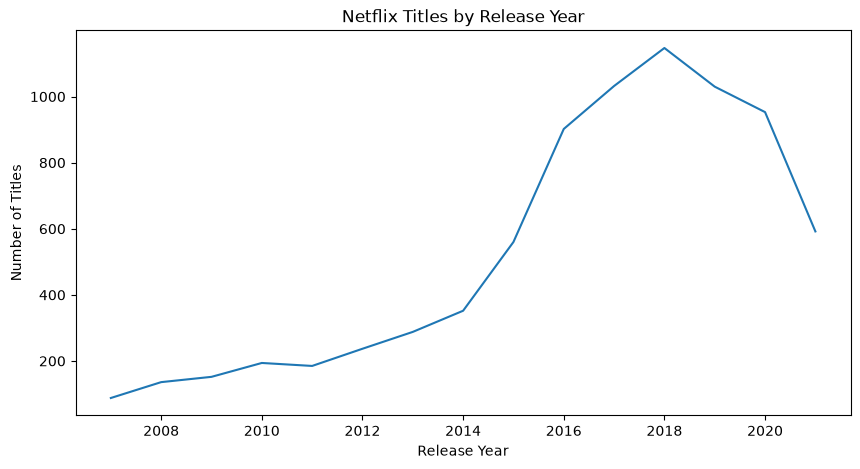

In [ ]:
df["release_year"].value_counts().sort_index().tail(15).plot(
    kind="line",
    figsize=(10, 5),
    title="Netflix Titles by Release Year"
)

plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

### Line Chart Interpretation

The line chart shows the number of Netflix titles by release year. The distribution indicates that the dataset contains a much larger number of titles from recent years compared with older years. The number of titles increases significantly in the later years, showing that Netflix's catalog is largely composed of relatively recent content.

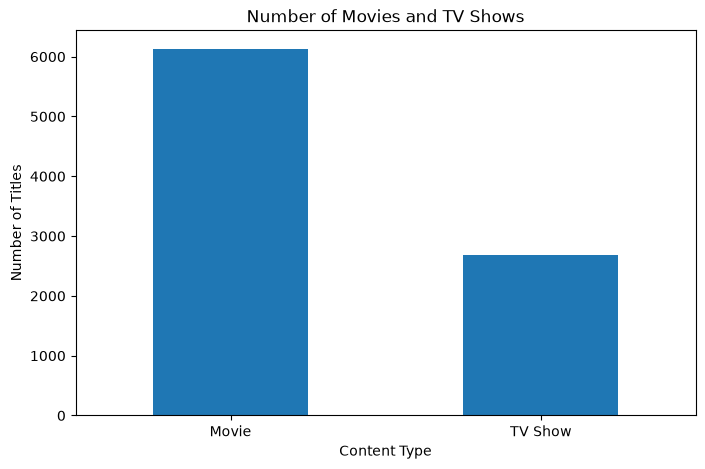

In [ ]:
type_counts = df["type"].value_counts()

plt.figure(figsize=(8, 5))
type_counts.plot(kind="bar")

plt.title("Number of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
plt.show()

### Bar Chart Interpretation

The bar chart compares the number of Movies and TV Shows in the Netflix dataset. Movies clearly represent the larger portion of the catalog, with 6,131 titles compared with 2,676 TV Shows. This shows that Movies are the dominant content type in the selected Netflix dataset.

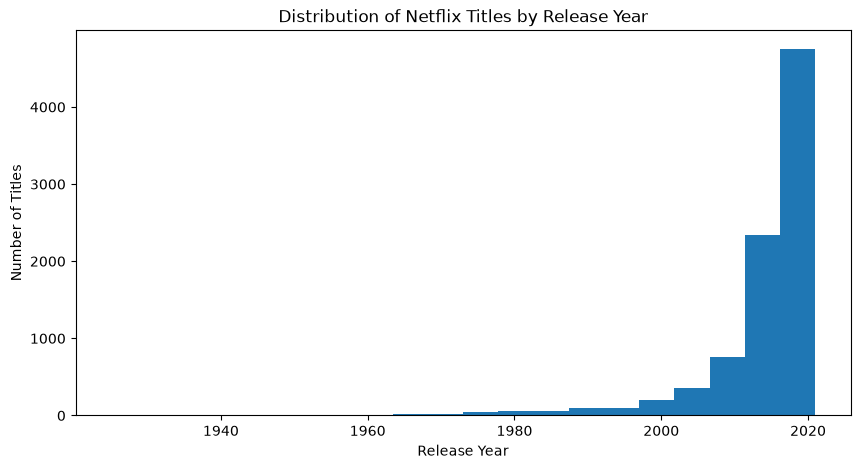

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(df["release_year"], bins=20)

plt.title("Distribution of Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

### Histogram Interpretation

The histogram shows the distribution of Netflix titles across different release years. The distribution is concentrated toward recent years, indicating that the dataset contains significantly more titles released in the later years. A smaller number of titles belong to older release periods.

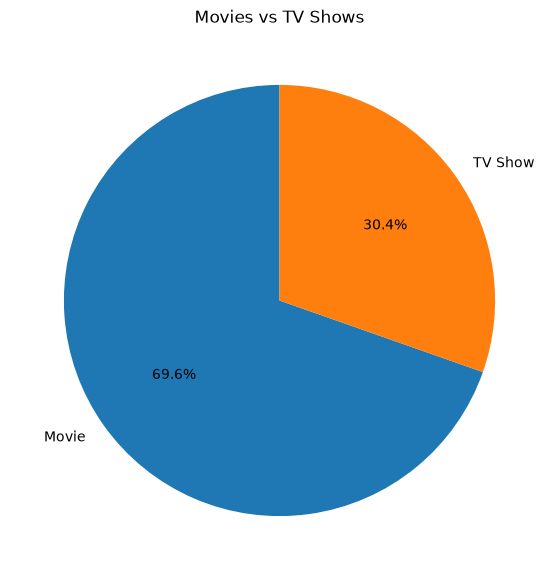

In [ ]:
type_counts = df["type"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Movies vs TV Shows")
plt.show()

### Pie Chart Interpretation

The pie chart shows the proportion of Movies and TV Shows in the Netflix dataset. Movies account for approximately 69.6% of the total titles, while TV Shows account for approximately 30.4%. Therefore, Movies make up the majority of the content represented in the dataset.

In [ ]:
year_counts = df["release_year"].value_counts().sort_index()

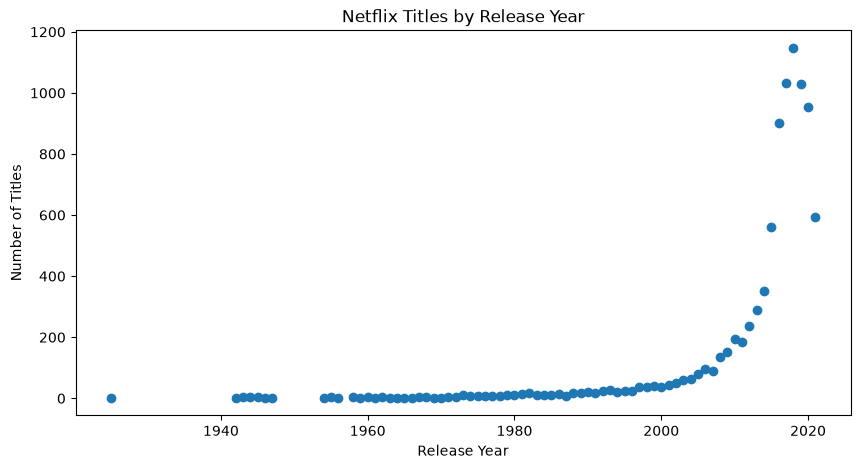

In [ ]:
plt.figure(figsize=(10, 5))

plt.scatter(year_counts.index, year_counts.values)

plt.title("Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

### Scatter Plot Interpretation

The scatter plot shows the relationship between release year and the number of Netflix titles in the dataset. The points are more concentrated in recent years, indicating that Netflix has a larger representation of newer content. Older years contain comparatively fewer titles.

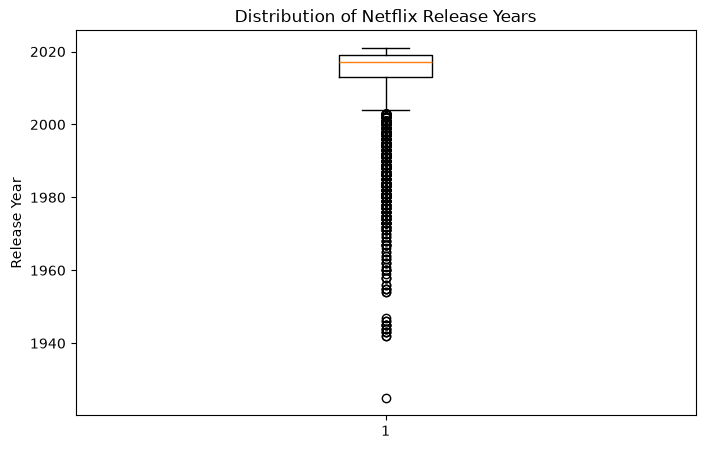

In [ ]:
plt.figure(figsize=(8, 5))

plt.boxplot(df["release_year"])

plt.title("Distribution of Netflix Release Years")
plt.ylabel("Release Year")

plt.show()

### Box Plot Interpretation

The box plot shows the distribution of release years in the Netflix dataset and helps identify the central tendency, spread, and potential outliers. Most release years are concentrated in the more recent period, while some much older titles appear as potential outliers. These older records are not necessarily errors because they represent historically released content.

In [ ]:
df["duration_value"] = df["duration"].str.extract(r"(\d+)").astype(float)

In [ ]:
numeric_df = df[["release_year", "duration_value"]]

correlation = numeric_df.corr()

correlation

,release_year,duration_value
release_year,1.000000,-0.249188
duration_value,-0.249188,1.000000


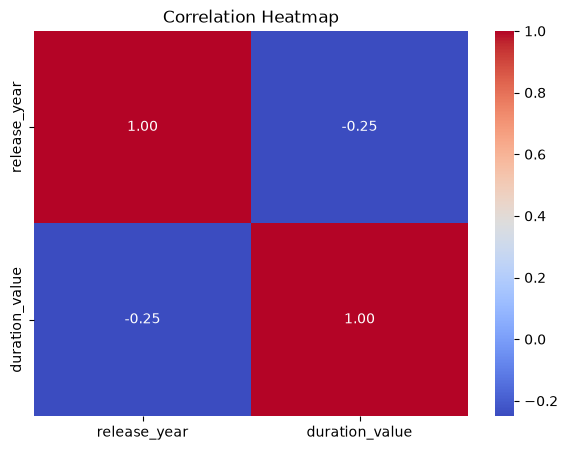

In [ ]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Correlation Heatmap Interpretation

The correlation heatmap shows the correlation between the numerical variables selected from the dataset. Correlation values range from -1 to +1, where values closer to +1 indicate a positive linear relationship, values closer to -1 indicate a negative relationship, and values near 0 indicate a weak or no linear relationship.

The actual correlation values will be interpreted based on the results obtained from the dataset.

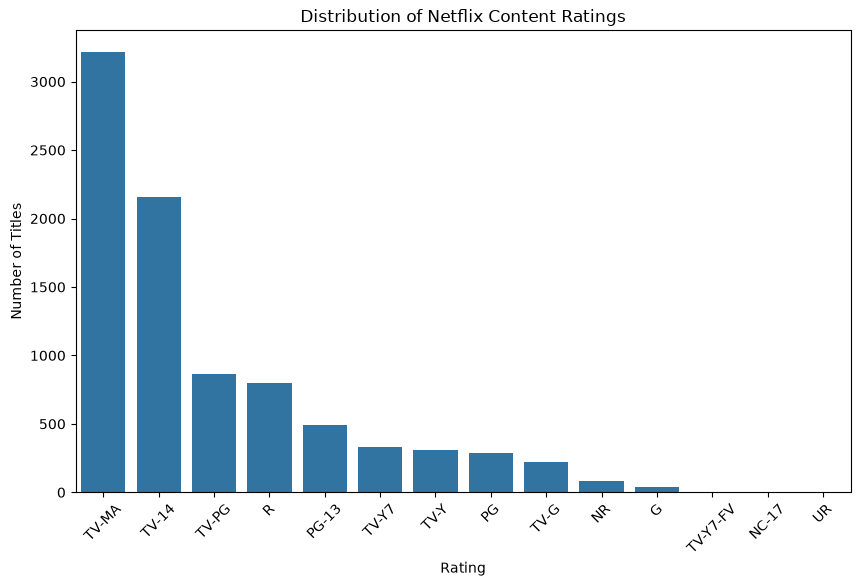

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="rating",
    order=df["rating"].value_counts().index
)

plt.title("Distribution of Netflix Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

### Count Plot Interpretation

The count plot shows the frequency of different content ratings in the Netflix dataset. TV-MA is the most frequently occurring rating, followed by TV-14 and TV-PG. This indicates that mature and teen-oriented content represents a significant portion of the titles in the dataset.

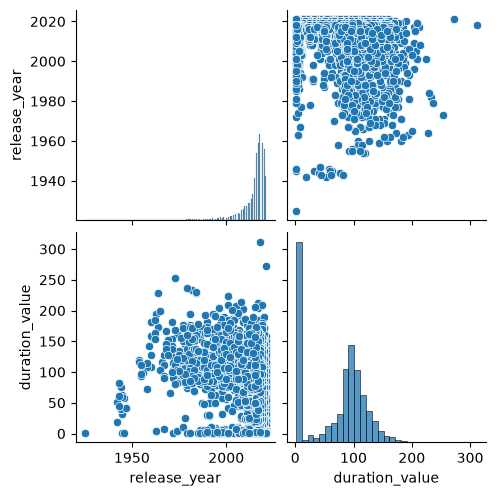

In [ ]:
pair_data = df[["release_year", "duration_value"]].dropna()

sns.pairplot(pair_data)

plt.show()

### Pair Plot Interpretation

The pair plot provides a visual overview of the relationships and distributions of the selected numerical variables. It helps identify the distribution of release years and duration values and provides an initial view of possible relationships between them. Since duration represents minutes for Movies and seasons for TV Shows, the duration variable should be interpreted carefully when comparing it with release year.

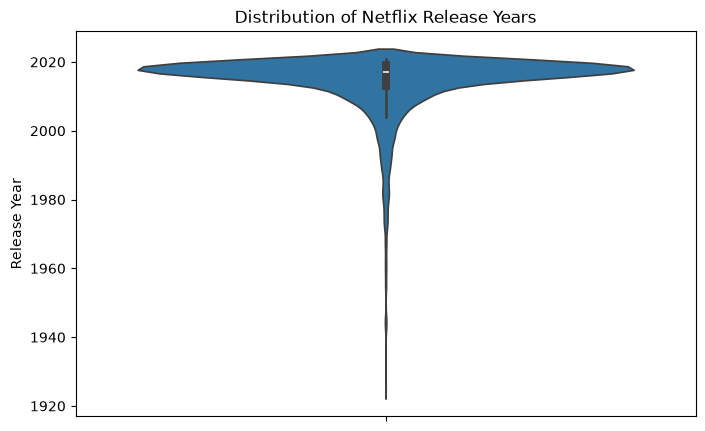

In [ ]:
plt.figure(figsize=(8, 5))

sns.violinplot(y=df["release_year"])

plt.title("Distribution of Netflix Release Years")
plt.ylabel("Release Year")

plt.show()

### Violin Plot Interpretation

The violin plot shows the distribution and density of Netflix release years. The distribution is concentrated toward recent release years, indicating that most titles in the dataset belong to newer periods. The wider sections represent areas where release years occur more frequently, while the narrower sections represent less frequent values.

# Part 5 – Data Insights & Findings

Based on the exploratory data analysis and statistical analysis, the following key insights were identified:

1. Movies are the dominant content type in the dataset, with 6,131 titles representing approximately 69.62% of all records.

2. TV Shows account for 2,676 titles, representing approximately 30.38% of the dataset.

3. TV-MA is the most common content rating, with 3,214 titles.

4. The United States is the most represented country, with 2,818 titles.

5. India is the second most represented country, with 972 titles.

6. The median release year is 2017, indicating that half of the titles have a release year at or below 2017 and half at or above 2017.

7. The mode release year is 2018, making it the most frequently occurring release year in the dataset.

8. The average release year is approximately 2014.18. The difference between the mean and median is influenced by older titles in the dataset.

9. The dataset covers a wide release period from 1925 to 2021, representing approximately 96 years of content.

10. The director column contains the highest amount of missing information, with 2,634 missing values, representing approximately 29.91% of the original dataset.

# Part 6 – Final Conclusion

This project analyzed the Netflix titles dataset as part of the Devixo Solutions AI/ML Internship Program Task 01. The dataset contained 8,807 records and 12 columns representing information such as content type, title, director, cast, country, release year, rating, duration, and description.

The analysis followed a complete data analysis workflow, including dataset loading, data understanding, missing-value analysis, duplicate detection, data-type conversion, invalid-value correction, exploratory data analysis, statistical analysis, and data visualization. Missing categorical values were handled using appropriate methods, the `date_added` column was converted into a datetime format, and three invalid duration values found in the rating column were corrected. Statistical analysis included mean, median, mode, standard deviation, variance, minimum, and maximum values. Multiple visualizations were created to understand content distribution, release-year patterns, ratings, relationships, and data distributions.

The analysis showed that Movies represent approximately 69.62% of the dataset, while TV Shows represent 30.38%. TV-MA was the most common rating, and the United States was the most represented country. The dataset contained titles released between 1925 and 2021, with recent years containing a much larger number of titles. Overall, this project provided practical experience in Python, Pandas, NumPy, Matplotlib, Seaborn, data cleaning, exploratory data analysis, statistical analysis, visualization, and insight generation. These skills provide a strong foundation for future AI/ML tasks involving feature engineering, machine learning, model training, and predictive analysis.

In [ ]:
df.shape

(8807, 13)

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   show_id         8807 non-null   str           
 1   type            8807 non-null   str           
 2   title           8807 non-null   str           
 3   director        8807 non-null   str           
 4   cast            8807 non-null   str           
 5   country         8807 non-null   str           
 6   date_added      8797 non-null   datetime64[us]
 7   release_year    8807 non-null   int64         
 8   rating          8807 non-null   str           
 9   duration        8807 non-null   str           
 10  listed_in       8807 non-null   str           
 11  description     8807 non-null   str           
 12  duration_value  8807 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(10)
memory usage: 894.6 KB


In [ ]:
df.isna().sum()

show_id            0
type               0
title              0
director           0
cast               0
country            0
date_added        10
release_year       0
rating             0
duration           0
listed_in          0
description        0
duration_value     0
dtype: int64